# Import necessary libraries

In [107]:
import pandas as pd # data operation and data Wrangling
import numpy as np # number operation in array
import matplotlib.pyplot as plt # data visualisation
import seaborn as sns # data visualisation
from sklearn.preprocessing import StandardScaler, OneHotEncoder # standardization , encoding for feature scaling
from sklearn.impute import SimpleImputer # handle missing values
from sklearn.compose import ColumnTransformer # apply preprocessing on columns
from sklearn.pipeline import Pipeline # combine preprocessing and model
from sklearn.model_selection import train_test_split # split the data into train, validation and test
from sklearn.ensemble import RandomForestClassifier # random forest
from xgboost import XGBClassifier # xgboost
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, classification_report, roc_curve, precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score # for evaluation metric
from IPython.display import display # show comparison tables nicely

# Load the CSV data

In [108]:
df = pd.read_csv(r"/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


# data visualization

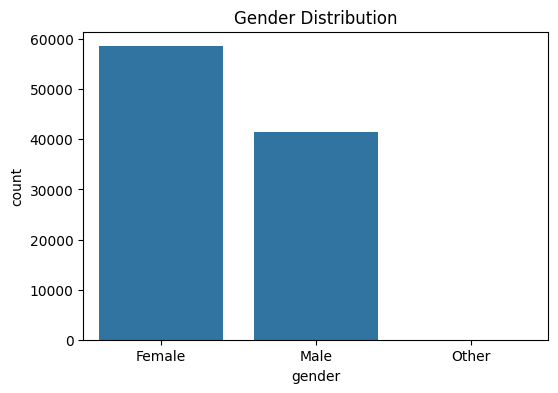

In [109]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

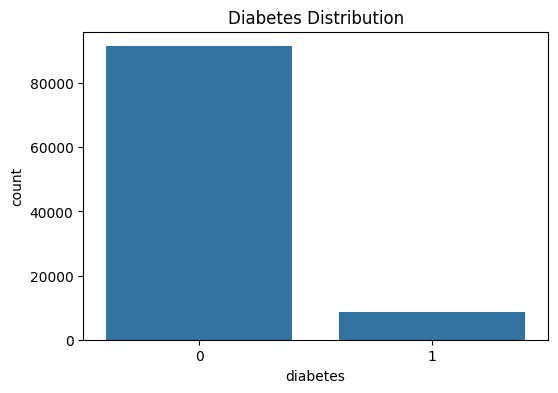

diabetes
0    91500
1     8500
Name: count, dtype: int64
Diabetes percentage: 8.50%


In [110]:
plt.figure(figsize=(6,4))
sns.countplot(x="diabetes", data=df)
plt.title("Diabetes Distribution")
plt.show()

print(df["diabetes"].value_counts())
print(f"Diabetes percentage: {df['diabetes'].mean() * 100:.2f}%")

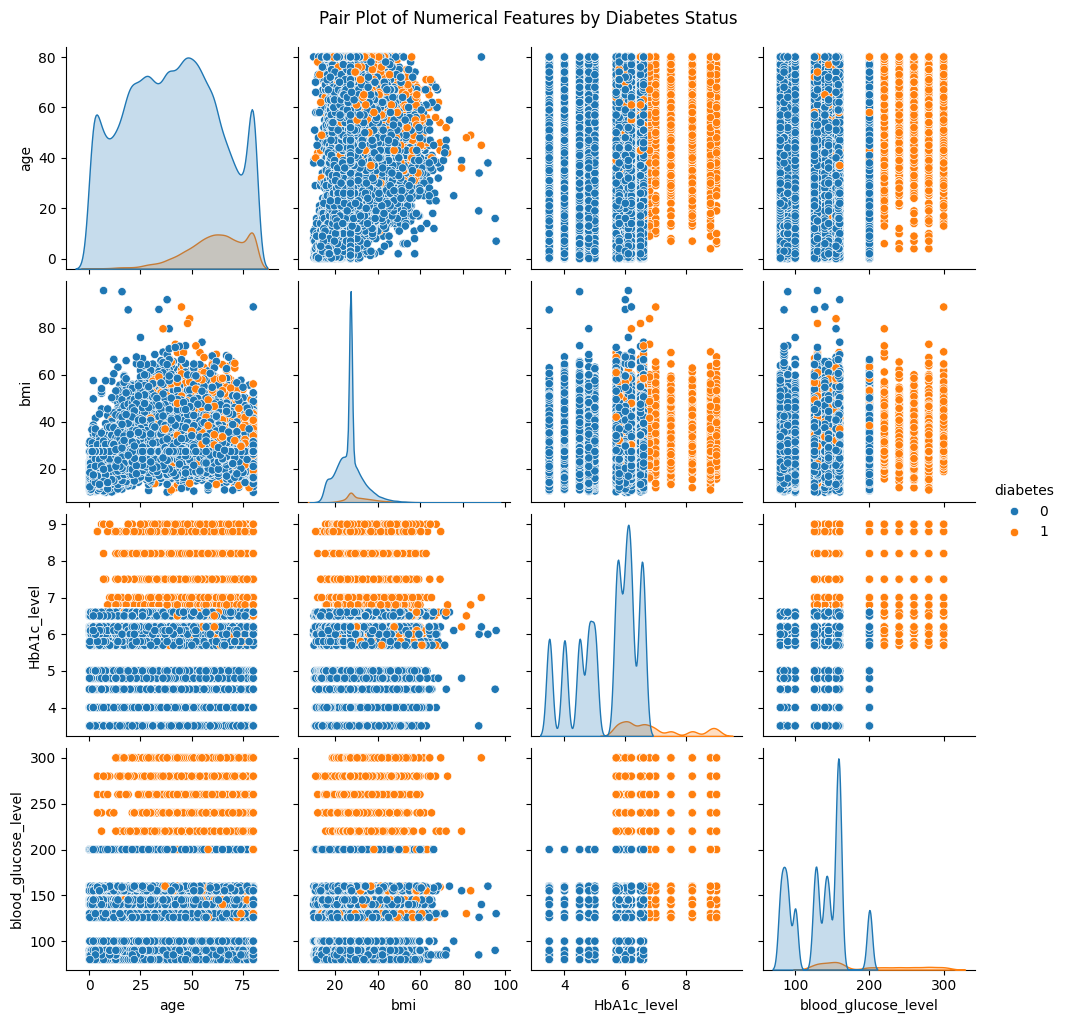

In [ ]:
sns.pairplot(df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']], hue='diabetes')
plt.suptitle('Pair Plot of Numerical Features by Diabetes Status', y=1.02) 
plt.show()

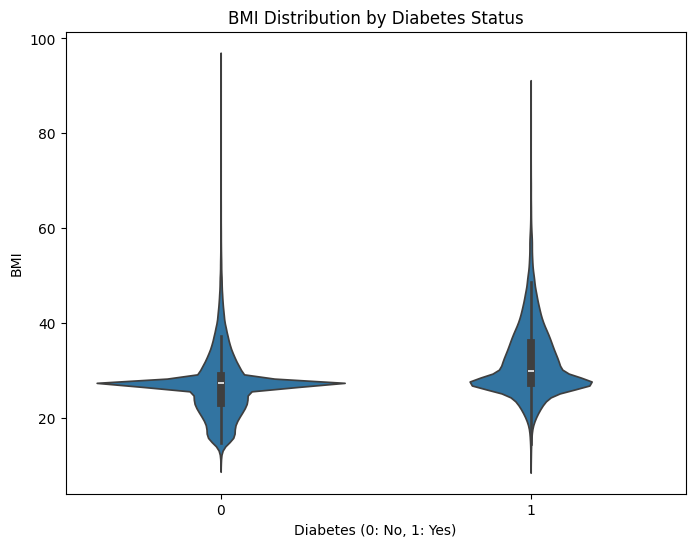

In [112]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='diabetes', y='bmi', data=df)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('BMI')
plt.show()

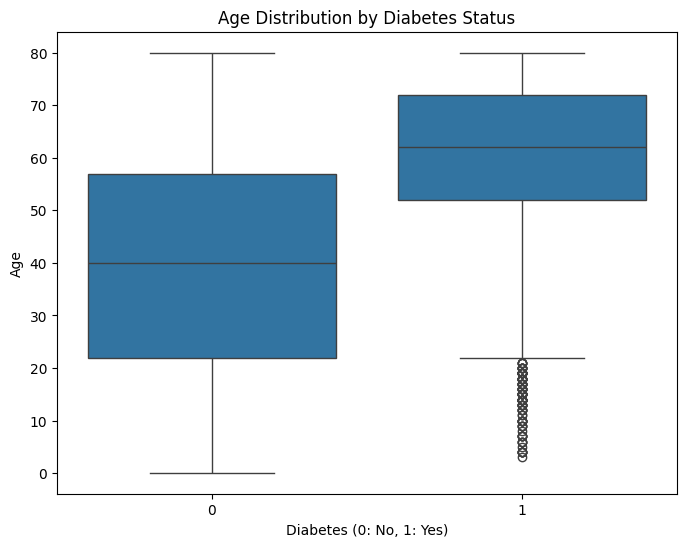

In [113]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

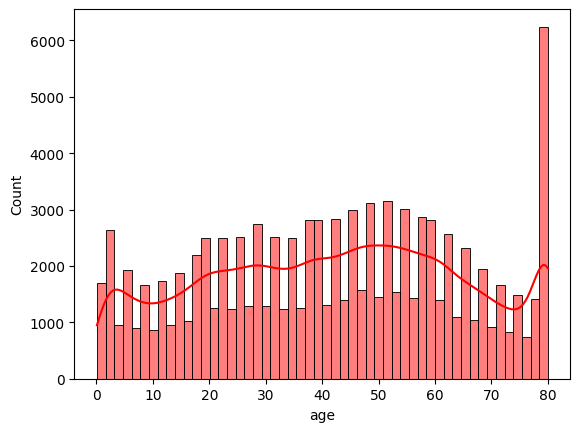

In [114]:
sns.histplot(df['age'], kde=True, color='red')
plt.show()

/tmp/ipykernel_57/2093500905.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='smoking_history', y='bmi', data=df, ci=None) # ci=None removes confidence intervals


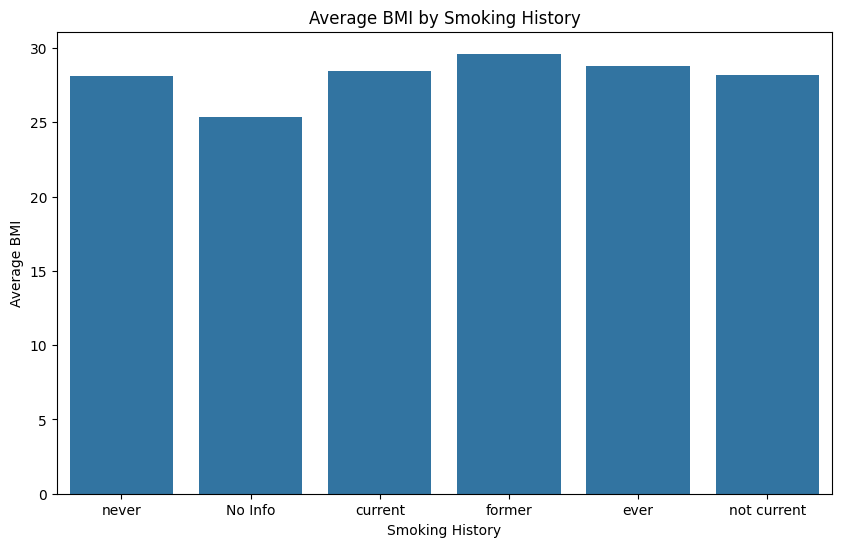

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='smoking_history', y='bmi', data=df, ci=None) #ci=None removes confidence intervals
plt.title('Average BMI by Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Average BMI')
plt.show()

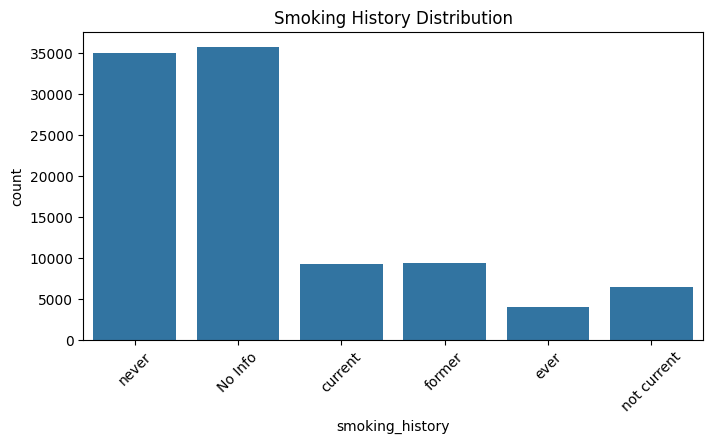

In [116]:
plt.figure(figsize=(8,4))
sns.countplot(x="smoking_history", data=df)
plt.title("Smoking History Distribution")
plt.xticks(rotation=45)
plt.show()

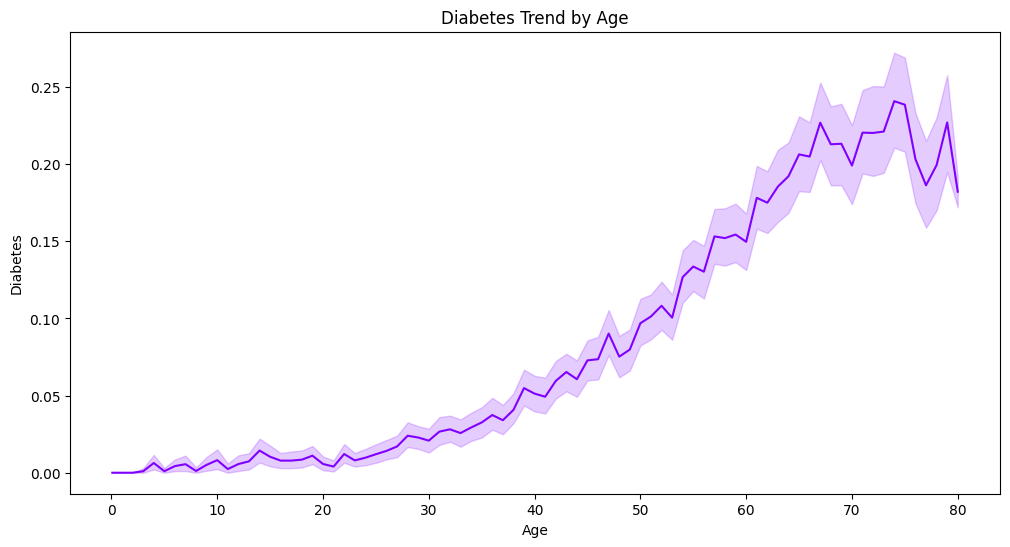

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(x=df['age'], y=df['diabetes'], color="#8000FF")
plt.title('Diabetes Trend by Age')
plt.xlabel('Age')
plt.ylabel('Diabetes')
plt.show()

# Data Preparation

In [118]:
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [119]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [120]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [121]:
df.dtypes

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [122]:
print(df.isnull().sum()) # check missing values

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [123]:
df.nunique() # check values possible in each feature

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

In [124]:
df[df.duplicated()].count() # check duplicated values

gender                 3854
age                    3854
hypertension           3854
heart_disease          3854
smoking_history        3854
bmi                    3854
HbA1c_level            3854
blood_glucose_level    3854
diabetes               3854
dtype: int64

In [125]:
df.drop_duplicates(inplace=True) # drop duplicated values
df.reset_index(drop=True, inplace=True)

In [126]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


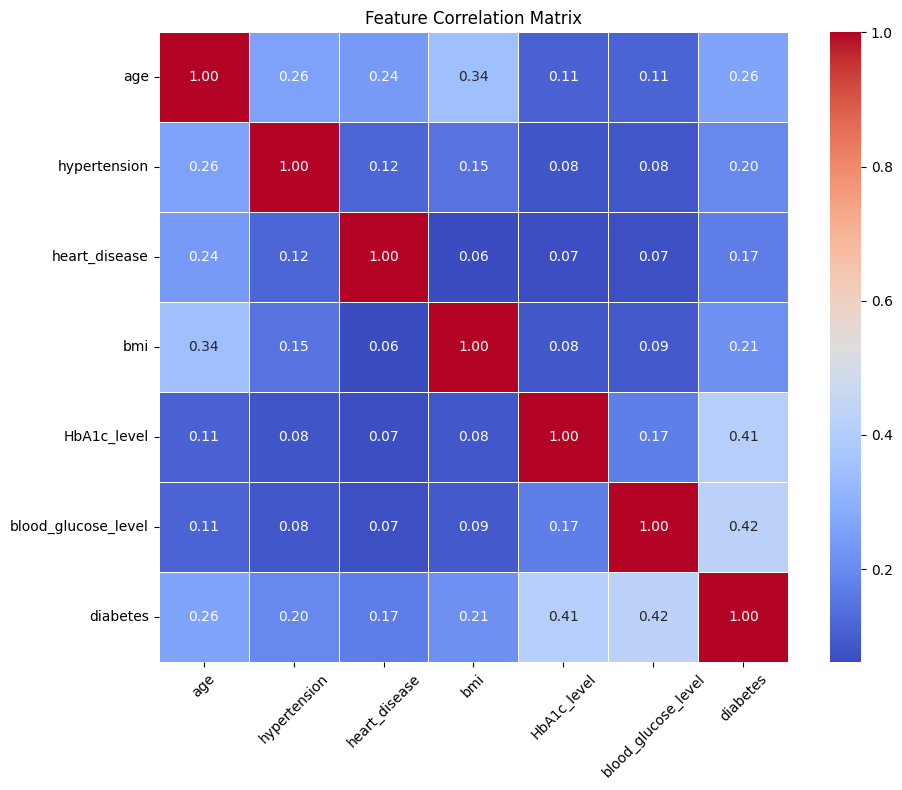

In [127]:
# Compute the correlation matrix for numerical features
corr_matrix = df[['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']].corr()

# Set up the plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)

# Title and display
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ENCODING AND SCALLING

In [ ]:
df['age_bmi'] = df['age'] * df['bmi']
df['age_hba1c'] = df['age'] * df['HbA1c_level']
df['bmi_glucose'] = df['bmi'] * df['blood_glucose_level']
df['hba1c_glucose'] = df['HbA1c_level'] * df['blood_glucose_level']
df['risk_factor_count'] = df['hypertension'] + df['heart_disease']
df['glucose_hba1c_ratio'] = df['blood_glucose_level'] / (df['HbA1c_level'] + 1e-6)

In [ ]:
categorical_cols = ['gender', 'smoking_history']
numerical_cols = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level',
    'age_bmi',
    'age_hba1c',
    'bmi_glucose',
    'hba1c_glucose',
    'risk_factor_count',
    'glucose_hba1c_ratio'
]
binary_cols = ['hypertension', 'heart_disease']

In [ ]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

binary_transformer = SimpleImputer(strategy='most_frequent')

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'bmi', 'HbA1c_level',
                                  'blood_glucose_level', 'age_bmi', 'age_hba1c',
                                  'bmi_glucose', 'hba1c_glucose',
                                  'risk_factor_count', 'glucose_hba1c_ratio']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'smoking_history']),
                                ('bin', SimpleImputer(strategy='most_frequent'),
                                 ['hypertension', 'heart_disease'])])

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('bin', binary_transformer, binary_cols)
])
preprocessor

# Split data into features and target

In [129]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Split data into training, validation and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

Train shape: (61532, 14)
Validation shape: (15384, 14)
Test shape: (19230, 14)


# Unbalanced data solution

In [ ]:
class_counts = y_train.value_counts()
scale_pos_weight = class_counts[0] / class_counts[1]
print(class_counts)
print(f"scale_weight: {scale_pos_weight:.2f}")

diabetes
0    56103
1     5429
Name: count, dtype: int64
scale_pos_weight: 10.33


# Random forest

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(max_depth=15,max_features='sqrt',min_samples_leaf=1,min_samples_split=5,n_estimators=200,class_weight='balanced',random_state=42,n_jobs=-1
    ))
])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level',
                                                   'age_bmi', 'age_hba1c',
                                                   'bmi_glucose',
                                                   'hba1c_glucose',
                                                   'risk_factor_count',
                                                   'glucose_hba1c_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('bin',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['hypertension',
                                                   'heart_disease'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_split=5, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [ ]:
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)
test_proba = rf_model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
roc_auc = roc_auc_score(y_test, test_proba)
avg_precision = average_precision_score(y_test, test_proba)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {avg_precision:.4f}")
print("\nClassification report:")
print(classification_report(y_test, test_pred))


Model Performance:
Training Accuracy: 0.9631
Test Accuracy: 0.9409
ROC-AUC: 0.9743
PR-AUC: 0.8735

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     17534
           1       0.63      0.82      0.71      1696

    accuracy                           0.94     19230
   macro avg       0.80      0.89      0.84     19230
weighted avg       0.95      0.94      0.94     19230



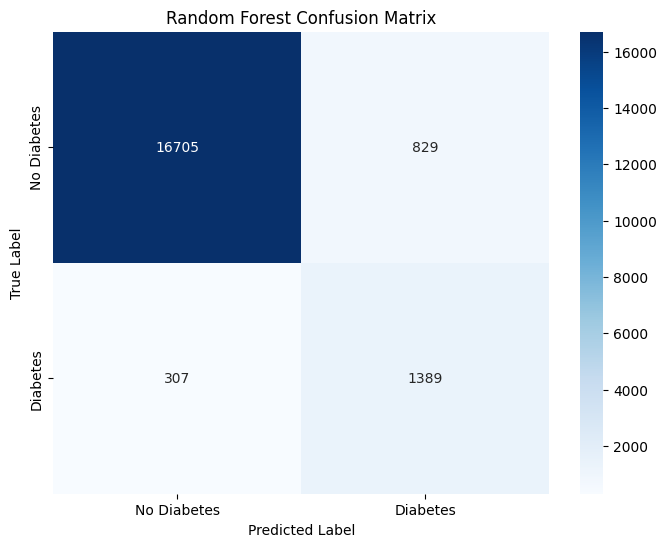

In [134]:
# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Before optimization: Base XGBoost

In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,objective='binary:logistic',eval_metric='logloss',random_state=42,n_jobs=-1))
])
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level',
                                                   'age_bmi', 'age_hba1c',
                                                   'bmi_glucose',
                                                   'hba1c_glucose',
                                                   'risk_factor_count',
                                                   'glucose_hba1c_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImp...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
before_train_pred = xgb_model.predict(X_train)
before_valid_pred = xgb_model.predict(X_valid)
before_test_pred = xgb_model.predict(X_test)

before_train_proba = xgb_model.predict_proba(X_train)[:, 1]
before_valid_proba = xgb_model.predict_proba(X_valid)[:, 1]
before_test_proba = xgb_model.predict_proba(X_test)[:, 1]

before_train_accuracy = accuracy_score(y_train, before_train_pred)
before_test_accuracy = accuracy_score(y_test, before_test_pred)
before_test_precision = precision_score(y_test, before_test_pred, zero_division=0)
before_test_recall = recall_score(y_test, before_test_pred, zero_division=0)
before_test_f1 = f1_score(y_test, before_test_pred, zero_division=0)
before_test_f2 = (5 * before_test_precision * before_test_recall) / ((4 * before_test_precision) + before_test_recall + 1e-9)
before_roc_auc = roc_auc_score(y_test, before_test_proba)
before_pr_auc = average_precision_score(y_test, before_test_proba)

In [ ]:
before_optimization_metrics = {
    'Model': 'Before Optimization - Base XGBoost',
    'Train Accuracy': before_train_accuracy,
    'Test Accuracy': before_test_accuracy,
    'Precision': before_test_precision,
    'Recall': before_test_recall,
    'F1 Score': before_test_f1,
    'F2 Score': before_test_f2,
    'ROC-AUC': before_roc_auc,
    'PR-AUC': before_pr_auc
}

print(f"Training Accuracy: {before_train_accuracy:.4f}")
print(f"Test Accuracy: {before_test_accuracy:.4f}")
print(f"Test Precision: {before_test_precision:.4f}")
print(f"Test Recall: {before_test_recall:.4f}")
print(f"Test F1-score: {before_test_f1:.4f}")
print(f"Test F2-score: {before_test_f2:.4f}")
print(f"ROC-AUC: {before_roc_auc:.4f}")
print(f"PR-AUC: {before_pr_auc:.4f}")
print("Classification report:")
print(classification_report(y_test, before_test_pred, zero_division=0))



Before Optimization - Base XGBoost Performance:
Training Accuracy: 0.9103
Test Accuracy: 0.9017
Test Precision: 0.4706
Test Recall: 0.9192
Test F1-score: 0.6225
Test F2-score: 0.7720
ROC-AUC: 0.9776
PR-AUC: 0.8843

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17534
           1       0.47      0.92      0.62      1696

    accuracy                           0.90     19230
   macro avg       0.73      0.91      0.78     19230
weighted avg       0.95      0.90      0.92     19230



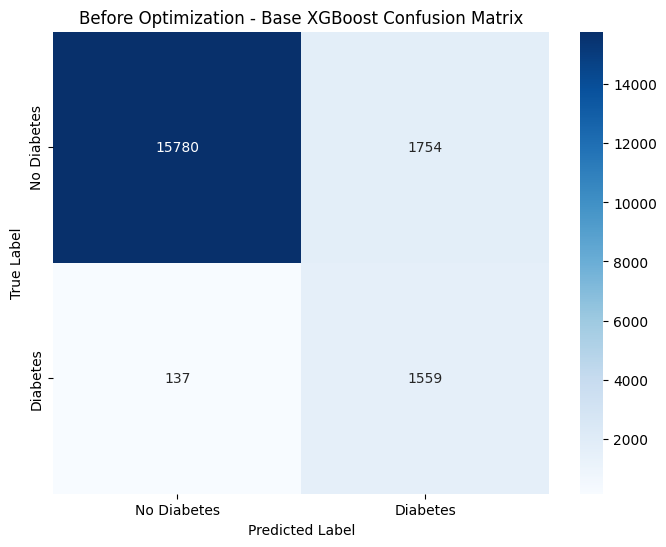

In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, before_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Before Optimization - Base XGBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# After optimization Gray Wolf Optimizer xgboost

In [ ]:
from IPython.display import display

bounds = {
'n_estimators': (350, 900),'max_depth': (2, 5),'learning_rate': (0.020, 0.100),'subsample': (0.80, 1.00),'colsample_bytree': (0.80, 1.00),'min_child_weight': (2, 9),'gamma': (0.0, 2.5),'reg_alpha': (0.0, 3.0),'reg_lambda': (2.0, 12.0),'max_delta_step': (0.0, 4.0),'scale_pos_weight_multiplier': (0.55, 1.35)
}

param_names = list(bounds.keys())
lower_bounds = np.array([bounds[name][0] for name in param_names], dtype=float)
upper_bounds = np.array([bounds[name][1] for name in param_names], dtype=float)
dim = len(param_names)

rng = np.random.default_rng(42)
fitness_cache = {}
history = []

In [139]:
def create_xgb_model(position):
    values = dict(zip(param_names, np.clip(position, lower_bounds, upper_bounds)))

    params = {
        'n_estimators': int(round(values['n_estimators'])),
        'max_depth': int(round(values['max_depth'])),
        'learning_rate': float(values['learning_rate']),
        'subsample': float(values['subsample']),
        'colsample_bytree': float(values['colsample_bytree']),
        'min_child_weight': float(values['min_child_weight']),
        'gamma': float(values['gamma']),
        'reg_alpha': float(values['reg_alpha']),
        'reg_lambda': float(values['reg_lambda']),
        'max_delta_step': float(values['max_delta_step']),
        'scale_pos_weight': float(scale_pos_weight * values['scale_pos_weight_multiplier']),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(**params))
    ])

    return model, params

In [ ]:
def balanced_score(valid_accuracy, valid_precision, valid_recall, valid_f1, valid_pr_auc, valid_roc_auc):
    valid_f2 = (5 * valid_precision * valid_recall) / ((4 * valid_precision) + valid_recall + 1e-9)
    score = (
        0.28 * valid_f2 +
        0.24 * valid_f1 +
        0.20 * valid_recall +
        0.12 * valid_precision +
        0.08 * valid_pr_auc +
        0.05 * valid_accuracy +
        0.03 * valid_roc_auc
    )
    score -= 0.50 * max(0, 0.50 - valid_precision)
    score -= 0.45 * max(0, 0.66 - valid_f1)
    score -= 0.35 * max(0, 0.91 - valid_accuracy)
    score -= 0.30 * max(0, 0.90 - valid_recall)
    score -= 0.20 * max(0, (valid_recall - valid_precision) - 0.43)

    return score, valid_f2

In [141]:
def fitness_function(position):
    clipped_position = np.clip(position, lower_bounds, upper_bounds)
    model, params = create_xgb_model(clipped_position)

    cache_key = tuple(
        round(params[name], 6) if isinstance(params[name], float) else params[name]
        for name in params
        if name not in ['objective', 'eval_metric', 'tree_method', 'random_state', 'n_jobs']
    )

    if cache_key in fitness_cache:
        return fitness_cache[cache_key]

    model.fit(X_train, y_train)

    valid_pred = model.predict(X_valid)
    valid_proba = model.predict_proba(X_valid)[:, 1]

    valid_accuracy = accuracy_score(y_valid, valid_pred)
    valid_precision = precision_score(y_valid, valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid, valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid, valid_pred, zero_division=0)
    valid_pr_auc = average_precision_score(y_valid, valid_proba)
    valid_roc_auc = roc_auc_score(y_valid, valid_proba)

    score, valid_f2 = balanced_score(
        valid_accuracy,
        valid_precision,
        valid_recall,
        valid_f1,
        valid_pr_auc,
        valid_roc_auc
    )

    metrics = {
        'Balanced Score': score,
        'Validation Accuracy': valid_accuracy,
        'Precision': valid_precision,
        'Recall': valid_recall,
        'F1 Score': valid_f1,
        'F2 Score': valid_f2,
        'PR-AUC': valid_pr_auc,
        'ROC-AUC': valid_roc_auc,
        'scale_pos_weight': params['scale_pos_weight']
    }

    result = (-score, metrics, params)
    fitness_cache[cache_key] = result
    return result

In [ ]:
def initialize_population(population_size):
    return rng.uniform(lower_bounds, upper_bounds, size=(population_size, dim))

def evaluate_population(population):
    fitness = []
    metrics_list = []
    params_list = []

    for position in population:
        current_fitness, current_metrics, current_params = fitness_function(position)
        fitness.append(current_fitness)
        metrics_list.append(current_metrics)
        params_list.append(current_params)

    return np.array(fitness), metrics_list, params_list


def update_position(position, alpha, beta, delta, a):
    A1 = 2 * a * rng.random(dim) - a
    C1 = 2 * rng.random(dim)
    D_alpha = np.abs(C1 * alpha - position)
    X1 = alpha - A1 * D_alpha

    A2 = 2 * a * rng.random(dim) - a
    C2 = 2 * rng.random(dim)
    D_beta = np.abs(C2 * beta - position)
    X2 = beta - A2 * D_beta

    A3 = 2 * a * rng.random(dim) - a
    C3 = 2 * rng.random(dim)
    D_delta = np.abs(C3 * delta - position)
    X3 = delta - A3 * D_delta

    new_position = (X1 + X2 + X3) / 3
    new_position = np.clip(new_position, lower_bounds, upper_bounds)

    return new_position

In [143]:
def grey_wolf_optimizer():
    population = initialize_population(14)

    alpha = None
    beta = None
    delta = None

    alpha_fitness = np.inf
    beta_fitness = np.inf
    delta_fitness = np.inf

    alpha_metrics = None
    alpha_params = None

    for iteration in range(18):
        fitness, metrics_list, params_list = evaluate_population(population)

        for wolf_index in range(14):
            current_fitness = fitness[wolf_index]
            current_position = population[wolf_index].copy()
            current_metrics = metrics_list[wolf_index]
            current_params = params_list[wolf_index]

            history.append({
                'Phase': 'GWO',
                'Iteration': iteration + 1,
                'Wolf': wolf_index + 1,
                'Fitness': current_fitness,
                **current_metrics
            })

            if current_fitness < alpha_fitness:
                delta_fitness = beta_fitness
                delta = None if beta is None else beta.copy()

                beta_fitness = alpha_fitness
                beta = None if alpha is None else alpha.copy()

                alpha_fitness = current_fitness
                alpha = current_position.copy()
                alpha_metrics = current_metrics.copy()
                alpha_params = current_params.copy()

            elif current_fitness < beta_fitness:
                delta_fitness = beta_fitness
                delta = None if beta is None else beta.copy()

                beta_fitness = current_fitness
                beta = current_position.copy()

            elif current_fitness < delta_fitness:
                delta_fitness = current_fitness
                delta = current_position.copy()

        if beta is None:
            beta = alpha.copy()
        if delta is None:
            delta = beta.copy()

        a = 2 - iteration * (2 / 18)

        for wolf_index in range(14):
            population[wolf_index] = update_position(
                population[wolf_index],
                alpha,
                beta,
                delta,
                a
            )

        print(
            f"Iteration {iteration + 1}/18 | "
            f"F1: {alpha_metrics['F1 Score']:.4f} | "
            f"Accuracy: {alpha_metrics['Validation Accuracy']:.4f} | "
            f"Score: {alpha_metrics['Balanced Score']:.4f}"
        )

    return alpha, alpha_fitness, alpha_metrics, alpha_params

In [144]:
best_position, best_fitness, best_metrics, best_params = grey_wolf_optimizer()

step_size = (upper_bounds - lower_bounds) * 0.06

for trial in range(20):
    candidate_position = best_position + rng.normal(0, step_size)
    candidate_position = np.clip(candidate_position, lower_bounds, upper_bounds)

    candidate_fitness, candidate_metrics, candidate_params = fitness_function(candidate_position)
    history.append({
        'Phase': 'Local Search',
        'Iteration': trial + 1,
        'Wolf': 0,
        'Fitness': candidate_fitness,
        **candidate_metrics
    })

    if candidate_fitness < best_fitness:
        best_position = candidate_position.copy()
        best_fitness = candidate_fitness
        best_metrics = candidate_metrics.copy()
        best_params = candidate_params.copy()

    step_size *= 0.92

print(
    "\nBest validation result after Balanced GWO:"
    f"\nF1 Score: {best_metrics['F1 Score']:.4f}"
    f"\nF2 Score: {best_metrics['F2 Score']:.4f}"
    f"\nAccuracy: {best_metrics['Validation Accuracy']:.4f}"
    f"\nPR-AUC: {best_metrics['PR-AUC']:.4f}"
    f"\nROC-AUC: {best_metrics['ROC-AUC']:.4f}"
)

print("\nBest XGBoost parameters from Balanced GWO:")
for key, value in best_params.items():
    print(f"{key}: {value}")

gwo_results_df = pd.DataFrame(history).sort_values(by='Balanced Score', ascending=False)
print("\nTop balanced validation results:")
display(gwo_results_df[[
    'Phase',
    'Iteration',
    'Wolf',
    'Validation Accuracy',
    'F1 Score',
    'F2 Score',
    'PR-AUC',
    'ROC-AUC',
    'Balanced Score',
    'scale_pos_weight'
]].head(10))

X_train_final = pd.concat([X_train, X_valid], axis=0)
y_train_final = pd.concat([y_train, y_valid], axis=0)

best_model_name = "Balanced GWO XGBoost"
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**best_params))
])

best_model.fit(X_train_final, y_train_final)

Iteration 1/18 | F1: 0.6649 | Accuracy: 0.9193 | Score: 0.7721
Iteration 2/18 | F1: 0.7124 | Accuracy: 0.9384 | Score: 0.7759
Iteration 3/18 | F1: 0.7124 | Accuracy: 0.9384 | Score: 0.7759
Iteration 4/18 | F1: 0.7140 | Accuracy: 0.9390 | Score: 0.7765
Iteration 5/18 | F1: 0.7140 | Accuracy: 0.9390 | Score: 0.7765
Iteration 6/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 7/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 8/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 9/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 10/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 11/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 12/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 13/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 14/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 15/18 | F1: 0.7063 | Accuracy: 0.9358 | Score: 0.7790
Iteration 16/18 | F1: 0.7063 | Accuracy: 0.9358 |

,Phase,Iteration,Wolf,Validation Accuracy,F1 Score,F2 Score,PR-AUC,ROC-AUC,Balanced Score,scale_pos_weight
270,Local Search,19,0,0.931422,0.695351,0.799044,0.887298,0.978522,0.779757,6.629716
225,GWO,17,2,0.931552,0.695577,0.798805,0.886835,0.978454,0.779416,6.558549
83,GWO,6,14,0.935777,0.706302,0.798924,0.886259,0.978100,0.779006,6.091684
228,GWO,17,5,0.927262,0.684877,0.797691,0.886894,0.978464,0.778948,7.231789
193,GWO,14,12,0.928302,0.687270,0.797578,0.887369,0.978674,0.778628,7.031567
236,GWO,17,13,0.928822,0.688478,0.797522,0.887033,0.978534,0.778422,6.965487
185,GWO,14,4,0.926157,0.681971,0.796808,0.886801,0.978430,0.778155,7.325374
271,Local Search,20,0,0.931422,0.694822,0.797689,0.887066,0.978541,0.778152,6.558315
184,GWO,14,3,0.924922,0.679078,0.796610,0.887038,0.978553,0.778104,7.511121
188,GWO,14,7,0.927132,0.684136,0.796588,0.887171,0.978486,0.777692,7.135082


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level',
                                                   'age_bmi', 'age_hba1c',
                                                   'bmi_glucose',
                                                   'hba1c_glucose',
                                                   'risk_factor_count',
                                                   'glucose_hba1c_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImp...
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.020335609542270774, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=1.2459115490922181, max_depth=4,
                               max_leaves=None,
                               min_child_weight=2.9787448897657343, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=685, n_jobs=-1,
                               num_parallel_tree=None, ...))])

# Final evaluation after optimization

In [ ]:
train_pred = best_model.predict(X_train_final)
test_pred = best_model.predict(X_test)

train_proba = best_model.predict_proba(X_train_final)[:, 1]
test_proba = best_model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train_final, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_f2 = (5 * test_precision * test_recall) / ((4 * test_precision) + test_recall + 1e-9)
roc_auc = roc_auc_score(y_test, test_proba)
avg_precision = average_precision_score(y_test, test_proba)

after_optimization_metrics = {
    'Model': 'After Optimization - Balanced GWO XGBoost',
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1 Score': test_f1,
    'F2 Score': test_f2,
    'ROC-AUC': roc_auc,
    'PR-AUC': avg_precision
}
print("After Optimization - Balanced GWO XGBoost Performance:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test F2-score: {test_f2:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {avg_precision:.4f}")
print("Classification report:")
print(classification_report(y_test, test_pred, zero_division=0))


After Optimization - Balanced GWO XGBoost Performance:
Training Accuracy: 0.9325
Test Accuracy: 0.9277
Test Precision: 0.5573
Test Recall: 0.8768
Test F1-score: 0.6815
Test F2-score: 0.7866
ROC-AUC: 0.9778
PR-AUC: 0.8849

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     17534
           1       0.56      0.88      0.68      1696

    accuracy                           0.93     19230
   macro avg       0.77      0.90      0.82     19230
weighted avg       0.95      0.93      0.93     19230



# Before vs After Optimization Comparison

In [ ]:
comparison_df = pd.DataFrame([
    before_optimization_metrics,
    after_optimization_metrics
])

metric_cols = [
    'Train Accuracy',
    'Test Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'F2 Score',
    'ROC-AUC',
    'PR-AUC'
]

comparison_display = comparison_df.copy()
for col in metric_cols:
    comparison_display[col] = comparison_display[col].map(lambda x: f"{x:.4f}")

display(comparison_display)

improvement = {
    'Metric': metric_cols,
    'Before': [before_optimization_metrics[col] for col in metric_cols],
    'After': [after_optimization_metrics[col] for col in metric_cols],
    'Change': [after_optimization_metrics[col] - before_optimization_metrics[col] for col in metric_cols]
}

improvement_df = pd.DataFrame(improvement)
improvement_display = improvement_df.copy()
for col in ['Before', 'After', 'Change']:
    improvement_display[col] = improvement_display[col].map(lambda x: f"{x:+.4f}" if col == 'Change' else f"{x:.4f}")

print("Improvement after Balanced GWO optimization:")
display(improvement_display)

if after_optimization_metrics['Recall'] >= before_optimization_metrics['Recall'] and after_optimization_metrics['F1 Score'] >= before_optimization_metrics['F1 Score']:
    print()
    print("Final decision: Balanced GWO-XGBoost improved recall and F1, so it is the better final model.")
elif after_optimization_metrics['Recall'] > before_optimization_metrics['Recall']:
    print()
    print("Final decision: Balanced GWO-XGBoost improved recall, but check precision and F1 before selecting it as final.")
elif after_optimization_metrics['F1 Score'] > before_optimization_metrics['F1 Score']:
    print()
    print("Final decision: Balanced GWO-XGBoost improved F1, so it is more balanced even if recall did not increase.")
else:
    print()
    print("Final decision: Base XGBoost is better on this run. Try increasing epoch or pop_size for stronger GWO search.")


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC
0,Before Optimization - Base XGBoost,0.9103,0.9017,0.4706,0.9192,0.6225,0.7720,0.9776,0.8843
1,After Optimization - Balanced GWO XGBoost,0.9325,0.9277,0.5573,0.8768,0.6815,0.7866,0.9778,0.8849



Improvement after Balanced GWO optimization:


,Metric,Before,After,Change
0,Train Accuracy,0.9103,0.9325,+0.0223
1,Test Accuracy,0.9017,0.9277,+0.0261
2,Precision,0.4706,0.5573,+0.0868
3,Recall,0.9192,0.8768,-0.0425
4,F1 Score,0.6225,0.6815,+0.0590
5,F2 Score,0.7720,0.7866,+0.0146
6,ROC-AUC,0.9776,0.9778,+0.0002
7,PR-AUC,0.8843,0.8849,+0.0007



Final decision: Balanced GWO-XGBoost improved F1, so it is more balanced even if recall did not increase.


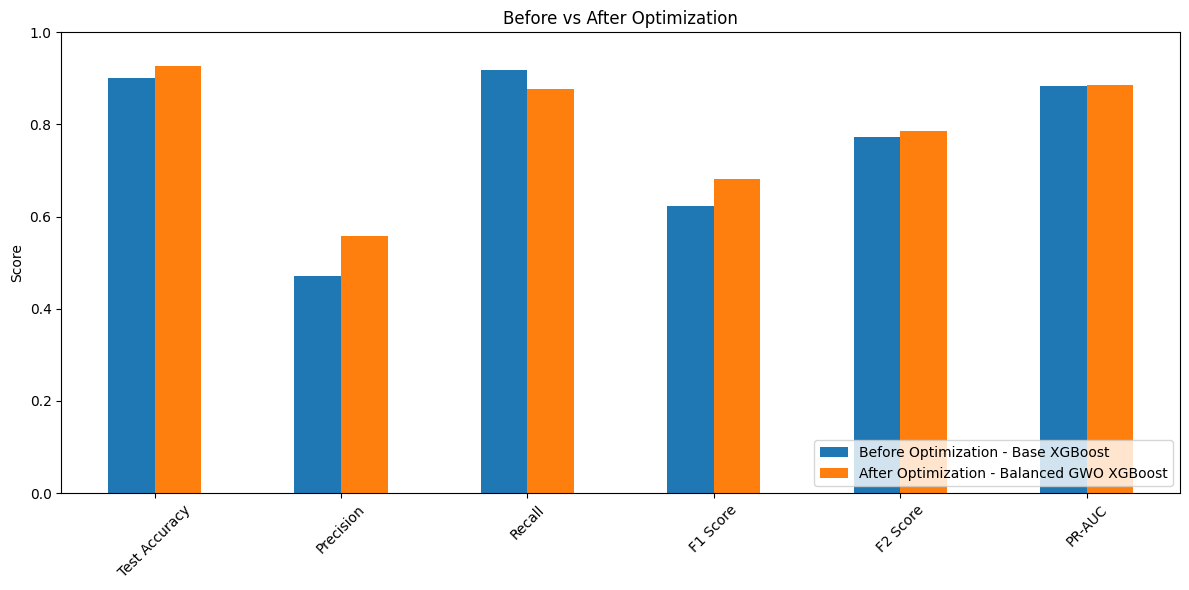

In [147]:
plot_df = comparison_df.set_index('Model')[['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score', 'PR-AUC']].T

ax = plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Before vs After Optimization')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# Check for overfitting

In [148]:
print(f"Difference (Training - Test): {train_accuracy - test_accuracy:.4f}")
if train_accuracy - test_accuracy > 0.1:
    print("Warning: Potential overfitting detected (large gap between training and test accuracy).")
else:
    print("No significant overfitting detected.")

Difference (Training - Test): 0.0048
No significant overfitting detected.


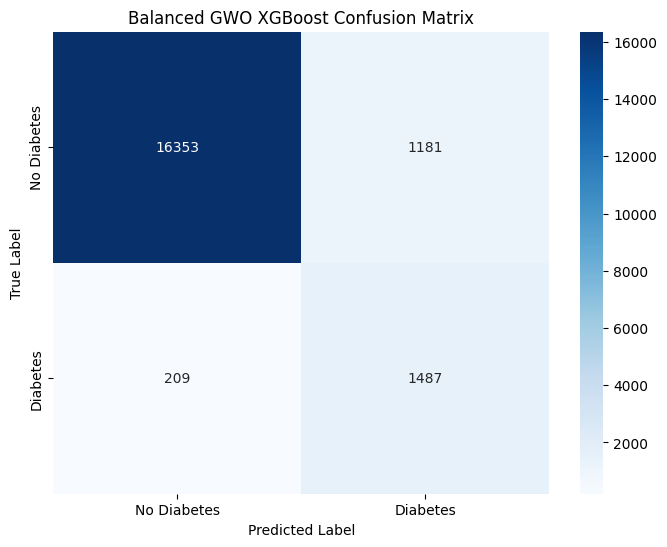

In [149]:
# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'{best_model_name} Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

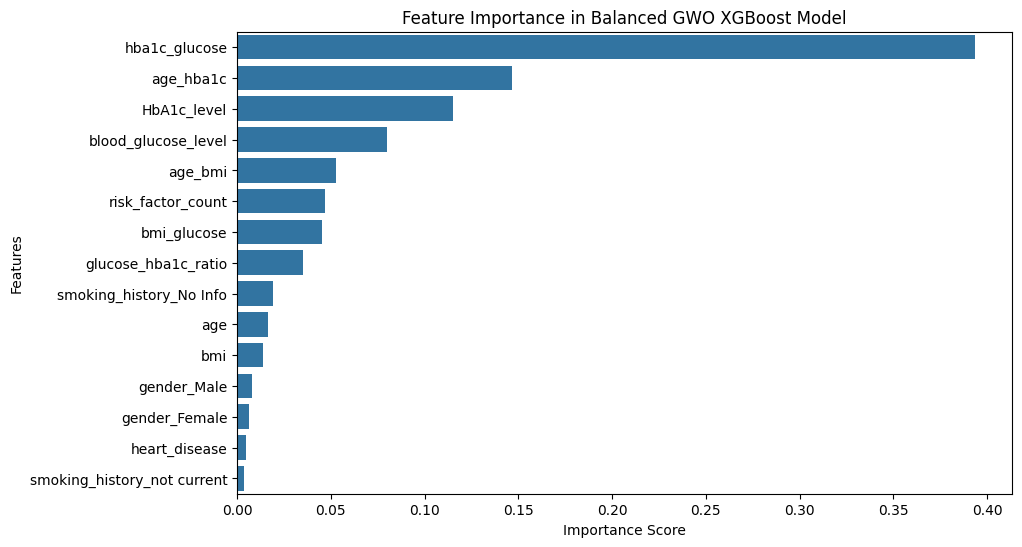

In [ ]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '').replace('bin__', '') for name in feature_names]
feature_importance = best_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title(f'Feature Importance in {best_model_name} Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


AUC-ROC: 0.98


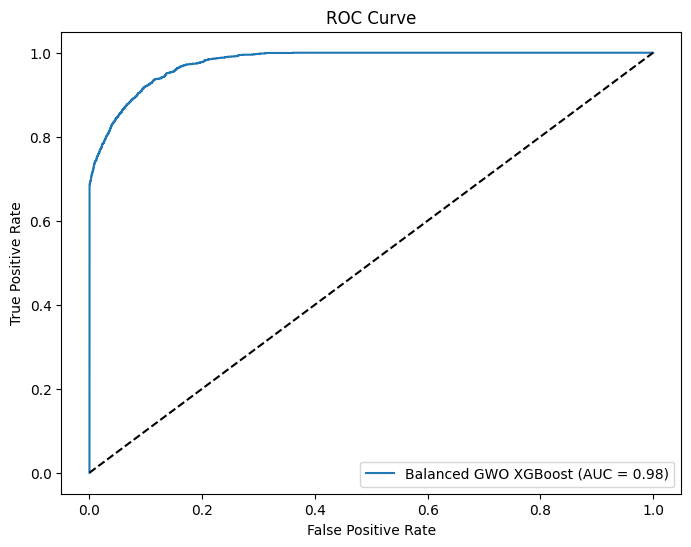

In [ ]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_proba)
roc_auc = roc_auc_score(y_test, test_proba)

print(f"\nAUC-ROC: {roc_auc:.2f}")
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Predictive model using Balanced GWO XGBoost

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def predict_diabetes(
    best_model,
    gender,
    age,
    hypertension,
    heart_disease,
    smoking_history,
    bmi,
    hba1c_level,
    blood_glucose_level
):
    # Create DataFrame
    new_data = pd.DataFrame({
        'gender': [gender],
        'age': [age],
        'hypertension': [int(hypertension)],
        'heart_disease': [int(heart_disease)],
        'smoking_history': [smoking_history],
        'bmi': [bmi],
        'HbA1c_level': [hba1c_level],
        'blood_glucose_level': [blood_glucose_level]
    })

    # Add the same engineered features used during training
    new_data['age_bmi'] = new_data['age'] * new_data['bmi']
    new_data['age_hba1c'] = new_data['age'] * new_data['HbA1c_level']
    new_data['bmi_glucose'] = new_data['bmi'] * new_data['blood_glucose_level']
    new_data['hba1c_glucose'] = new_data['HbA1c_level'] * new_data['blood_glucose_level']
    new_data['risk_factor_count'] = new_data['hypertension'] + new_data['heart_disease']
    new_data['glucose_hba1c_ratio'] = new_data['blood_glucose_level'] / (new_data['HbA1c_level'] + 1e-6)

    # Make prediction without threshold tuning
    prediction_proba = best_model.predict_proba(new_data)[:, 1][0]
    prediction = int(best_model.predict(new_data)[0])

    # Return results as a dictionary
    result = {
        "prediction": "Diabetes" if prediction == 1 else "No Diabetes",
        "probability_no_diabetes": f"{(1 - prediction_proba) * 100:.1f}%",
        "probability_diabetes": f"{prediction_proba * 100:.1f}%",
        "risk_level": (
            "High" if prediction_proba > 0.7
            else "Moderate" if prediction_proba > 0.3
            else "Low"
        )
    }

    return result


gender_options = sorted(df['gender'].dropna().unique().tolist())
smoking_history_options = sorted(df['smoking_history'].dropna().unique().tolist())
default_smoking = 'never' if 'never' in smoking_history_options else smoking_history_options[0]

gender_widget = widgets.Dropdown(
    options=gender_options,
    value=gender_options[0],
    description='Gender:',
    disabled=False,
)

age_widget = widgets.IntSlider(
    value=50,
    min=0,
    max=100,
    step=1,
    description='Age:',
    continuous_update=False,
)

hypertension_widget = widgets.Checkbox(
    value=False,
    description='Hypertension:',
    disabled=False,
)

heart_disease_widget = widgets.Checkbox(
    value=False,
    description='Heart Disease:',
    disabled=False,
)

smoking_history_widget = widgets.Dropdown(
    options=smoking_history_options,
    value=default_smoking,
    description='Smoking History:',
    disabled=False,
)

bmi_widget = widgets.FloatSlider(
    value=25.0,
    min=10.0,
    max=50.0,
    step=0.1,
    description='BMI:',
    continuous_update=False,
)

hba1c_level_widget = widgets.FloatSlider(
    value=5.7,
    min=3.0,
    max=10.0,
    step=0.1,
    description='HbA1c Level (%):',
    continuous_update=False,
)

blood_glucose_level_widget = widgets.IntSlider(
    value=100,
    min=50,
    max=300,
    step=1,
    description='Blood Glucose (mg/dL):',
    continuous_update=False,
)


output_widget = widgets.Output()


predict_button = widgets.Button(description="Predict Diabetes")

def on_predict_button_clicked(b):
    with output_widget:
        clear_output() 
        try:
            result = predict_diabetes(
                best_model=best_model,
                gender=gender_widget.value,
                age=age_widget.value,
                hypertension=hypertension_widget.value,
                heart_disease=heart_disease_widget.value,
                smoking_history=smoking_history_widget.value,
                bmi=bmi_widget.value,
                hba1c_level=hba1c_level_widget.value,
                blood_glucose_level=blood_glucose_level_widget.value
            )
            print("--- Prediction Results ---")
            print(f"Prediction: {result['prediction']}")
            print(f"Probability (No Diabetes): {result['probability_no_diabetes']}")
            print(f"Probability (Diabetes): {result['probability_diabetes']}")
            print(f"Risk Level: {result['risk_level']}")
        except Exception as e:
            print(f"An error occurred: {e}")


predict_button.on_click(on_predict_button_clicked)

input_widgets = widgets.VBox([
    gender_widget,
    age_widget,
    hypertension_widget,
    heart_disease_widget,
    smoking_history_widget,
    bmi_widget,
    hba1c_level_widget,
    blood_glucose_level_widget,
    predict_button
])

print("Diabetes Prediction GUI")
display(input_widgets, output_widget)


Diabetes Prediction GUI


Output()